# ETF Factor Hedge Model

This notebook introduces a second modeling scheme for the competition. Instead of ranking assets versus a single sector ETF, it treats the ETF panel as the factor set and models the selected asset returns as targets explained by those ETF factors.

The hedge step then sweeps a beta-reduction control from `0` to `1`. A value of `0` applies no factor hedge, while a value of `1` targets full offset of the estimated factor beta vector.

## 1. Setup

Load the daily data, define the ETF factors and target assets, and import the shared utilities from `src`.

In [21]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 16)
plt.style.use("ggplot")

SECTOR_UNIVERSE = {
    "Technology / Semiconductor": {
        "equities": ["NVDA", "AMD", "INTC", "AVGO", "QCOM", "TSM", "ASML", "MU"],
        "etf": "SOXX",
    },
    "Financial / Banking": {
        "equities": ["JPM", "BAC", "MS", "GS", "C", "WFC", "PNC", "USB"],
        "etf": "XLF",
    },
    "Energy / Infrastructure": {
        "equities": ["XOM", "CVX", "COP", "SLB", "EOG", "MPC", "VLO", "DVN"],
        "etf": "XLE",
    },
    "Healthcare / Biotech": {
        "equities": ["LLY", "UNH", "JNJ", "ABBV", "MRK", "AMGN", "PFE", "BMY"],
        "etf": "XLV",
    },
}

SEEN_SECTORS = [
    "Technology / Semiconductor",
    "Financial / Banking",
    "Energy / Infrastructure",
]
HIDDEN_SECTOR = "Healthcare / Biotech"
LOOKBACK_DAYS = 60
HOLD_DAYS = 5
TRANSACTION_COST_BPS = 10.0
STARTING_NAV = 1_000_000.0
BETA_REDUCTION_GRID = np.linspace(0.0, 1.0, 11)

raw_data = pd.read_csv("../data/daily_data.csv", header=[0, 1], index_col=0, parse_dates=True)
adj_close = raw_data["Adj Close"].sort_index().dropna(how="all").ffill()

FACTOR_ETFS = sorted({config["etf"] for config in SECTOR_UNIVERSE.values()})
SEEN_ASSETS = sorted(
    ticker
    for sector_name in SEEN_SECTORS
    for ticker in SECTOR_UNIVERSE[sector_name]["equities"]
)
HIDDEN_ASSETS = SECTOR_UNIVERSE[HIDDEN_SECTOR]["equities"]

CODE_PATH = Path.cwd().resolve()
if str(CODE_PATH) not in sys.path:
    sys.path.insert(0, str(CODE_PATH))

from src import build_vectorbt_portfolio, compute_weight_diagnostics, performance_summary

print(f"Loaded {adj_close.shape[1]} tickers across {adj_close.shape[0]} daily rows.")
print(f"Using ETF factors: {FACTOR_ETFS}")
print(f"Seen assets: {len(SEEN_ASSETS)} | Hidden assets: {len(HIDDEN_ASSETS)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 36 tickers across 2515 daily rows.
Using ETF factors: ['SOXX', 'XLE', 'XLF', 'XLV']
Seen assets: 24 | Hidden assets: 8


## 2. Factor Matrix And Target Universe

Build the ETF factor return matrix and the target return matrix for the selected assets.

In [22]:
factor_returns = adj_close[FACTOR_ETFS].pct_change()
target_returns = adj_close[sorted(SEEN_ASSETS + HIDDEN_ASSETS)].pct_change()
common_index = factor_returns.index.intersection(target_returns.index)
factor_returns = factor_returns.loc[common_index].dropna(how="all")
target_returns = target_returns.loc[common_index].dropna(how="all")

display(factor_returns.tail())
display(target_returns.iloc[-5:, :8])

Ticker,SOXX,XLE,XLF,XLV
2026-05-18,-0.024876,0.019179,0.012525,0.004273
2026-05-19,0.001754,0.011720,-0.012370,0.010980
2026-05-20,0.047449,-0.024311,0.010959,-0.001290
2026-05-21,0.008457,-0.011204,0.001355,0.006933
2026-05-22,0.024051,0.006088,0.004060,0.011745


Ticker,ABBV,AMD,AMGN,ASML,AVGO,BAC,BMY,C
2026-05-18,-0.004658,-0.007333,-0.005884,-0.019590,-0.010536,0.018485,0.005439,-0.008183
2026-05-19,0.020773,-0.016485,0.019606,-0.008795,-0.022914,0.000197,0.017449,-0.019933
2026-05-20,-0.006830,0.080981,0.002479,0.062140,0.016275,0.010454,0.003944,0.040427
2026-05-21,0.010363,0.004491,0.017643,0.027011,-0.007636,0.005075,0.017253,0.003205
2026-05-22,0.005594,0.039859,0.005572,0.025691,-0.001037,0.006021,-0.001511,-0.001038


## 3. Rolling ETF Factor Model

Estimate rolling multi-factor ETF betas for each selected asset using a trailing lookback window, then aggregate those betas into a portfolio-level factor exposure vector.

In [23]:
def estimate_factor_loadings(asset_window: pd.DataFrame, factor_window: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    x = factor_window.to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(x)), x])

    alphas = pd.Series(index=asset_window.columns, dtype=float)
    betas = pd.DataFrame(index=asset_window.columns, columns=factor_window.columns, dtype=float)

    for asset in asset_window.columns:
        y = asset_window[asset].to_numpy(dtype=float)
        valid = np.isfinite(y) & np.isfinite(x).all(axis=1)
        if valid.sum() < len(factor_window.columns) + 5:
            continue

        coefficients, _, _, _ = np.linalg.lstsq(x[valid], y[valid], rcond=None)
        alphas.loc[asset] = coefficients[0]
        betas.loc[asset] = coefficients[1:]

    return alphas, betas


def build_factor_hedge_weights(
    prices: pd.DataFrame,
    selected_assets: list[str],
    factor_etfs: list[str],
    beta_reduction: float,
    lookback_days: int = LOOKBACK_DAYS,
    hold_days: int = HOLD_DAYS,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    returns = prices[selected_assets + factor_etfs].pct_change().dropna()
    weights = pd.DataFrame(0.0, index=returns.index, columns=selected_assets + factor_etfs)

    portfolio_beta_history = []
    residual_beta_history = []
    asset_weight = 1.0 / len(selected_assets)
    dates = returns.index

    for idx in range(lookback_days, len(dates), hold_days):
        window_returns = returns.iloc[idx - lookback_days:idx]
        asset_window = window_returns[selected_assets]
        factor_window = window_returns[factor_etfs]
        _, factor_betas = estimate_factor_loadings(asset_window, factor_window)

        portfolio_beta = factor_betas.astype(float).mean(axis=0).fillna(0.0)
        residual_beta = (1.0 - beta_reduction) * portfolio_beta

        trade_dates = dates[idx:min(idx + hold_days, len(dates))]
        for trade_date in trade_dates:
            weights.loc[trade_date, selected_assets] = asset_weight
            weights.loc[trade_date, factor_etfs] = (-beta_reduction * portfolio_beta).values

        portfolio_beta_history.append(pd.Series(portfolio_beta, name=dates[idx - 1]))
        residual_beta_history.append(pd.Series(residual_beta, name=dates[idx - 1]))

    price_matrix = prices.loc[weights.index, weights.columns].ffill().dropna(how="all")
    weights = weights.reindex(price_matrix.index).fillna(0.0)

    portfolio_beta_history = pd.DataFrame(portfolio_beta_history)
    residual_beta_history = pd.DataFrame(residual_beta_history)
    return price_matrix, weights, portfolio_beta_history, residual_beta_history


def run_factor_hedge_model(
    prices: pd.DataFrame,
    selected_assets: list[str],
    factor_etfs: list[str],
    beta_reduction: float,
    lookback_days: int = LOOKBACK_DAYS,
    hold_days: int = HOLD_DAYS,
    transaction_cost_bps: float = TRANSACTION_COST_BPS,
    starting_nav: float = STARTING_NAV,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.DataFrame]:
    price_matrix, weights, portfolio_beta_history, residual_beta_history = build_factor_hedge_weights(
        prices=prices,
        selected_assets=selected_assets,
        factor_etfs=factor_etfs,
        beta_reduction=beta_reduction,
        lookback_days=lookback_days,
        hold_days=hold_days,
    )

    portfolio = build_vectorbt_portfolio(
        prices=price_matrix,
        target_weights=weights,
        starting_nav=starting_nav,
        transaction_cost_bps=transaction_cost_bps,
    )
    diagnostics = compute_weight_diagnostics(
        prices=price_matrix,
        target_weights=weights,
        portfolio=portfolio,
        transaction_cost_bps=transaction_cost_bps,
    )

    summary = performance_summary(
        diagnostics["return"],
        diagnostics["nav"],
        gross_exposure=diagnostics["gross_exposure"],
        turnover=diagnostics["turnover"],
        transaction_cost=diagnostics["transaction_cost"],
    )
    summary["beta_reduction"] = float(beta_reduction)
    summary["avg_factor_beta_l1"] = float(portfolio_beta_history.abs().sum(axis=1).mean())
    summary["avg_residual_beta_l1"] = float(residual_beta_history.abs().sum(axis=1).mean())

    if summary["avg_factor_beta_l1"] > 0:
        reduction_ratio = 1.0 - summary["avg_residual_beta_l1"] / summary["avg_factor_beta_l1"]
    else:
        reduction_ratio = 0.0

    summary["residual_beta_reduction_pct"] = float(reduction_ratio)
    return diagnostics, summary, portfolio_beta_history, residual_beta_history

In [24]:
sample_window_asset = target_returns[SEEN_ASSETS].dropna().tail(LOOKBACK_DAYS)
sample_window_factor = factor_returns.loc[sample_window_asset.index, FACTOR_ETFS]
sample_alphas, sample_betas = estimate_factor_loadings(sample_window_asset, sample_window_factor)

display(sample_betas.round(3).head(10))
sample_alphas.dropna().sort_values(ascending=False).head()

Ticker,SOXX,XLE,XLF,XLV
Ticker,,,,
AMD,1.353,-0.362,-0.268,-0.719
ASML,0.856,-0.433,0.057,0.483
AVGO,0.595,0.122,0.493,-0.157
BAC,0.025,-0.046,1.281,-0.075
C,0.141,-0.226,1.445,-0.137
COP,-0.108,1.101,0.156,-0.255
CVX,-0.097,0.943,-0.015,-0.039
DVN,0.041,1.305,-0.120,-0.254
EOG,-0.060,1.059,-0.064,-0.097


Ticker
AMD     0.005197
INTC    0.004994
QCOM    0.002878
EOG     0.001620
MPC     0.001376
dtype: float64

## 4. Hedge Optimization Across The Beta-Reduction Vector

Sweep the hedge intensity from `0` to `1`, score each candidate on the seen sectors, and pick the best hedge level subject to meaningful beta reduction.

In [25]:
seen_results = {}
grid_rows = []

for beta_reduction in BETA_REDUCTION_GRID:
    diagnostics, summary, portfolio_beta_history, residual_beta_history = run_factor_hedge_model(
        prices=adj_close,
        selected_assets=SEEN_ASSETS,
        factor_etfs=FACTOR_ETFS,
        beta_reduction=float(beta_reduction),
    )

    seen_results[float(beta_reduction)] = {
        "diagnostics": diagnostics,
        "summary": summary,
        "portfolio_beta_history": portfolio_beta_history,
        "residual_beta_history": residual_beta_history,
    }
    grid_rows.append(summary.rename(float(beta_reduction)))

seen_grid = pd.DataFrame(grid_rows)
seen_grid.index.name = "beta_reduction"
eligible = seen_grid[seen_grid["residual_beta_reduction_pct"] >= 0.50]
if eligible.empty:
    eligible = seen_grid

best_beta_reduction = float(eligible["score_sr"].idxmax())
best_seen = seen_results[best_beta_reduction]

display(seen_grid[[
    "annualized_return",
    "sortino",
    "max_drawdown",
    "score_sr",
    "avg_gross_exposure",
    "avg_residual_beta_l1",
    "residual_beta_reduction_pct",
]].round(4))
print(f"Best beta reduction selected on seen sectors: {best_beta_reduction:.2f}")

,annualized_return,sortino,max_drawdown,score_sr,avg_gross_exposure,avg_residual_beta_l1,residual_beta_reduction_pct
beta_reduction,,,,,,,
0.0,0.2497,1.3526,0.4821,0.7006,0.9761,1.2371,0.0
0.1,0.2291,1.3808,0.4431,0.7690,1.0969,1.1134,0.1
0.2,0.2081,1.4111,0.4020,0.8438,1.2176,0.9897,0.2
0.3,0.1865,1.4442,0.3588,0.9260,1.3384,0.8660,0.3
0.4,0.1646,1.4809,0.3133,1.0169,1.4592,0.7423,0.4
0.5,0.1422,1.5225,0.2670,1.1160,1.5799,0.6186,0.5
0.6,0.1194,1.5694,0.2195,1.2248,1.7007,0.4948,0.6
0.7,0.0964,1.6181,0.1701,1.3429,1.8214,0.3711,0.7
0.8,0.0730,1.6424,0.1185,1.4478,1.9422,0.2474,0.8


Best beta reduction selected on seen sectors: 0.80


,score_sr,residual_beta_reduction_pct
beta_reduction,,
0.0,0.700573,0.0
0.1,0.768980,0.1
0.2,0.843829,0.2
0.3,0.926044,0.3
0.4,1.016919,0.4
0.5,1.116043,0.5
0.6,1.224811,0.6
0.7,1.342879,0.7
0.8,1.447790,0.8


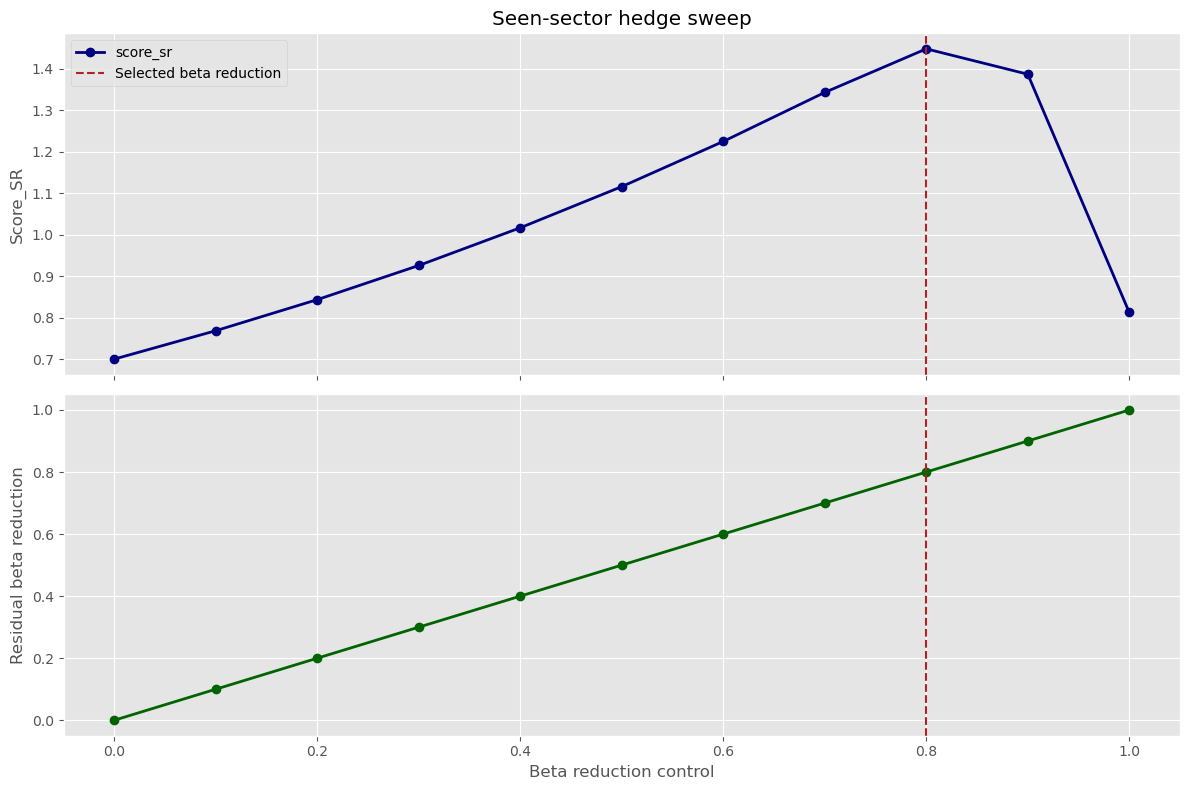

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

seen_grid["score_sr"].plot(ax=axes[0], marker="o", color="navy", lw=2, title="Seen-sector hedge sweep")
axes[0].axvline(best_beta_reduction, color="firebrick", linestyle="--", label="Selected beta reduction")
axes[0].set_ylabel("Score_SR")
axes[0].legend()

seen_grid["residual_beta_reduction_pct"].plot(ax=axes[1], marker="o", color="darkgreen", lw=2)
axes[1].axvline(best_beta_reduction, color="firebrick", linestyle="--")
axes[1].set_ylabel("Residual beta reduction")
axes[1].set_xlabel("Beta reduction control")

plt.tight_layout()
seen_grid[["score_sr", "residual_beta_reduction_pct"]]

## 5. Hidden-Sector Validation

Apply the selected beta-reduction level to the hidden sector and compare the seen-sector fit to the hidden-sector outcome.

In [27]:
hidden_diagnostics, hidden_summary, hidden_beta_history, hidden_residual_beta_history = run_factor_hedge_model(
    prices=adj_close,
    selected_assets=HIDDEN_ASSETS,
    factor_etfs=FACTOR_ETFS,
    beta_reduction=best_beta_reduction,
)

comparison_table = pd.DataFrame([best_seen["summary"], hidden_summary], index=["seen", "hidden"])
if comparison_table.loc["seen", "sortino"] != 0.0:
    comparison_table.loc["hidden", "generalization_index"] = comparison_table.loc["hidden", "sortino"] / comparison_table.loc["seen", "sortino"]

comparison_table.loc["hidden", "capital_efficiency"] = comparison_table.loc["hidden", "sortino"] * (
    1.0 - hidden_diagnostics["gross_exposure"].quantile(0.95) / 20.0
)

display(comparison_table.round(4))
print(f"Selected beta reduction carried into hidden sector: {best_beta_reduction:.2f}")

,annualized_return,sortino,max_drawdown,score_sr,observations,avg_gross_exposure,gross_exposure_p95,avg_daily_turnover,...,total_cost_pct,cost_drag_bps,beta_reduction,avg_factor_beta_l1,avg_residual_beta_l1,residual_beta_reduction_pct,generalization_index,capital_efficiency
seen,0.073,1.6424,0.1185,1.4478,2514.0,1.9422,2.1414,0.0093,...,0.0234,233.5972,0.8,1.2371,0.2474,0.8,NaN,NaN
hidden,0.076,1.5790,0.0871,1.4414,2514.0,1.9764,2.2948,0.0145,...,0.0364,363.5186,0.8,1.2809,0.2562,0.8,0.9614,1.3978


Selected beta reduction carried into hidden sector: 0.80


,annualized_return,sortino,max_drawdown,score_sr,observations,avg_gross_exposure,gross_exposure_p95,avg_daily_turnover,...,total_cost_pct,cost_drag_bps,beta_reduction,avg_factor_beta_l1,avg_residual_beta_l1,residual_beta_reduction_pct,generalization_index,capital_efficiency
seen,0.072992,1.642401,0.118492,1.447790,2514.0,1.942195,2.141402,0.009292,...,0.023360,233.597171,0.8,1.237113,0.247423,0.8,NaN,NaN
hidden,0.075999,1.578983,0.087118,1.441425,2514.0,1.976379,2.294823,0.014460,...,0.036352,363.518611,0.8,1.280872,0.256174,0.8,0.961387,1.397808


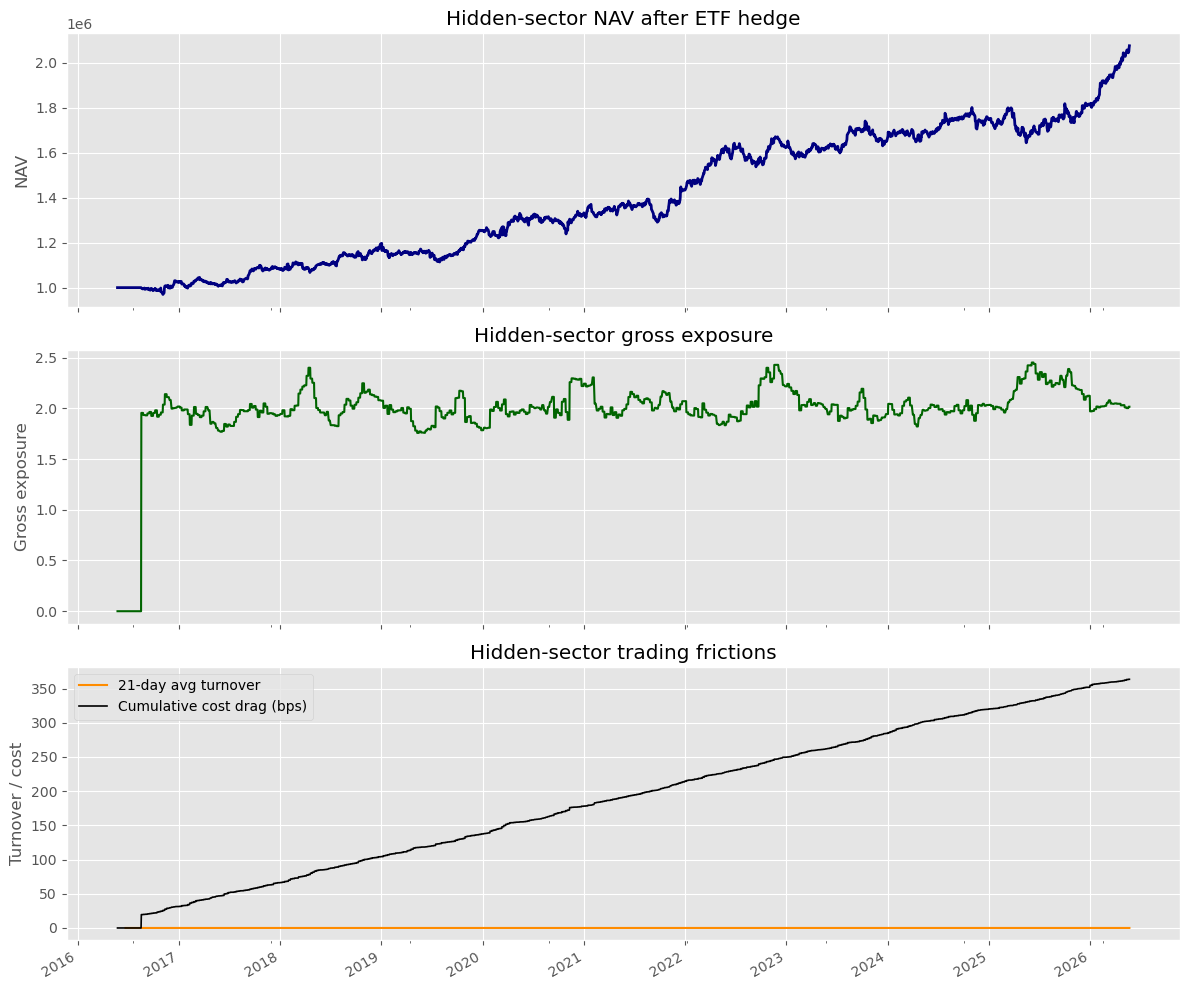

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

hidden_diagnostics["nav"].plot(ax=axes[0], color="navy", lw=2, title="Hidden-sector NAV after ETF hedge")
axes[0].set_ylabel("NAV")

hidden_diagnostics["gross_exposure"].plot(ax=axes[1], color="darkgreen", lw=1.5, title="Hidden-sector gross exposure")
axes[1].set_ylabel("Gross exposure")

hidden_diagnostics["turnover"].rolling(21).mean().plot(
    ax=axes[2],
    color="darkorange",
    lw=1.5,
    label="21-day avg turnover",
)
(hidden_diagnostics["transaction_cost"].cumsum() * 10_000).plot(
    ax=axes[2],
    color="black",
    lw=1.2,
    label="Cumulative cost drag (bps)",
)
axes[2].set_ylabel("Turnover / cost")
axes[2].set_title("Hidden-sector trading frictions")
axes[2].legend()

plt.tight_layout()
comparison_table

## 6. Alpha Attribution

Define portfolio alpha as the realized portfolio return minus the factor return explained by the residual post-hedge ETF beta vector. In symbols, $$\alpha_t = r_{p,t} - \beta_{\text{residual},t-1}^{\top} f_t,$$ where $r_{p,t}$ is the realized portfolio return and $f_t$ is the ETF factor return vector.

,annualized_factor_return,annualized_alpha_gross,annualized_alpha_net,avg_daily_alpha_net,cumulative_alpha_net
seen,0.0450,0.0357,0.0276,0.0001,0.3057
hidden,0.0157,0.0678,0.0602,0.0002,0.7830


,annualized_factor_return,annualized_alpha_gross,annualized_alpha_net,avg_daily_alpha_net,cumulative_alpha_net
seen,0.044991,0.035733,0.027605,0.000110,0.305667
hidden,0.015732,0.067799,0.060185,0.000239,0.783039


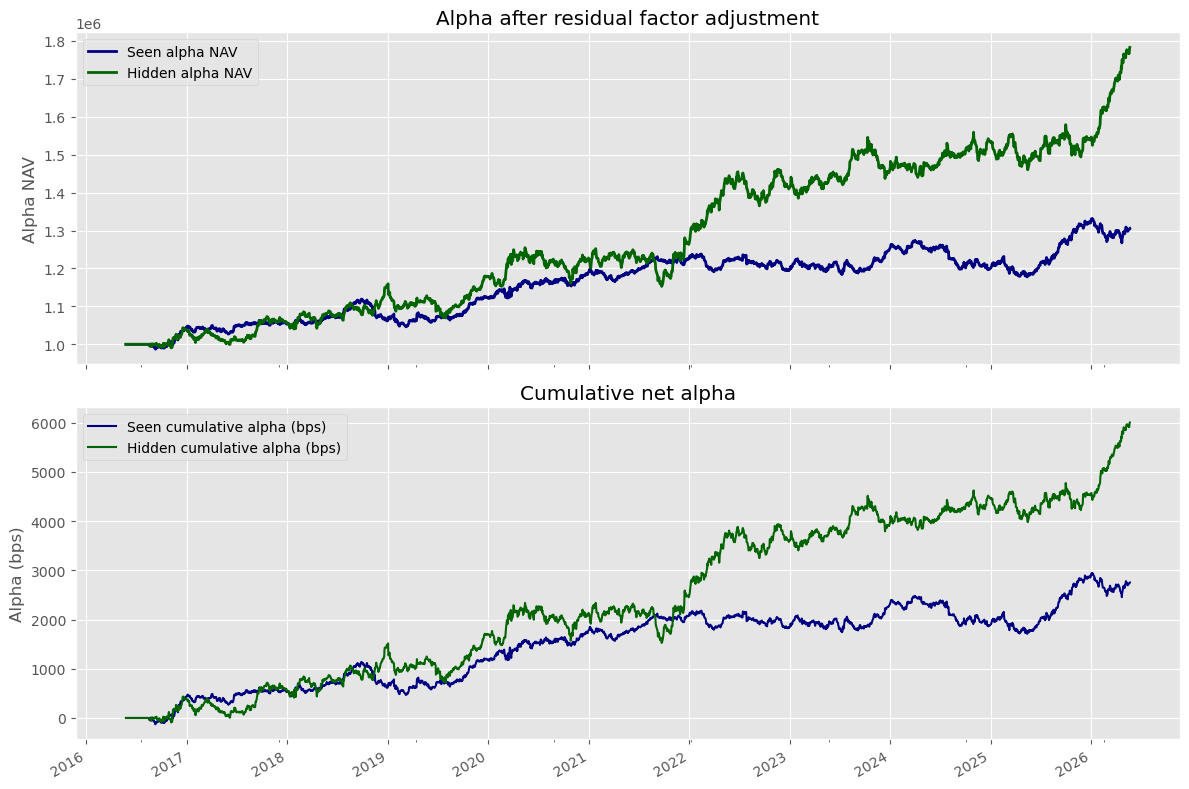

In [29]:
def compute_alpha_attribution(
    diagnostics: pd.DataFrame,
    residual_beta_history: pd.DataFrame,
    factor_returns: pd.DataFrame,
    label: str,
) -> tuple[pd.DataFrame, pd.Series]:
    aligned_betas = residual_beta_history.reindex(diagnostics.index, method="ffill").fillna(0.0)
    aligned_factors = factor_returns.reindex(diagnostics.index).fillna(0.0)[aligned_betas.columns]
    explained_factor_return = aligned_betas.mul(aligned_factors, axis=0).sum(axis=1)
    alpha_gross = diagnostics["gross_return"].fillna(0.0) - explained_factor_return
    alpha_net = diagnostics["return"].fillna(0.0) - explained_factor_return

    alpha_frame = pd.DataFrame(
        {
            "explained_factor_return": explained_factor_return,
            "alpha_gross": alpha_gross,
            "alpha_net": alpha_net,
            "alpha_nav": STARTING_NAV * (1.0 + alpha_net).cumprod(),
        },
        index=diagnostics.index,
)

    alpha_summary = pd.Series(
        {
            "annualized_factor_return": float(explained_factor_return.mean() * 252),
            "annualized_alpha_gross": float(alpha_gross.mean() * 252),
            "annualized_alpha_net": float(alpha_net.mean() * 252),
            "avg_daily_alpha_net": float(alpha_net.mean()),
            "cumulative_alpha_net": float((1.0 + alpha_net).prod() - 1.0),
        },
        name=label,
)
    return alpha_frame, alpha_summary


seen_alpha_frame, seen_alpha_summary = compute_alpha_attribution(
    diagnostics=best_seen["diagnostics"],
    residual_beta_history=best_seen["residual_beta_history"],
    factor_returns=factor_returns,
    label="seen",
)
hidden_alpha_frame, hidden_alpha_summary = compute_alpha_attribution(
    diagnostics=hidden_diagnostics,
    residual_beta_history=hidden_residual_beta_history,
    factor_returns=factor_returns,
    label="hidden",
)

alpha_table = pd.DataFrame([seen_alpha_summary, hidden_alpha_summary])
display(alpha_table.round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
seen_alpha_frame["alpha_nav"].plot(ax=axes[0], color="navy", lw=2, label="Seen alpha NAV")
hidden_alpha_frame["alpha_nav"].plot(ax=axes[0], color="darkgreen", lw=2, label="Hidden alpha NAV")
axes[0].set_title("Alpha after residual factor adjustment")
axes[0].set_ylabel("Alpha NAV")
axes[0].legend()

(seen_alpha_frame["alpha_net"].cumsum() * 10_000).plot(
    ax=axes[1],
    color="navy",
    lw=1.5,
    label="Seen cumulative alpha (bps)",
)
(hidden_alpha_frame["alpha_net"].cumsum() * 10_000).plot(
    ax=axes[1],
    color="darkgreen",
    lw=1.5,
    label="Hidden cumulative alpha (bps)",
)
axes[1].set_title("Cumulative net alpha")
axes[1].set_ylabel("Alpha (bps)")
axes[1].legend()

plt.tight_layout()
alpha_table

## 7. Hedge Validation And Attribution

Compare the selected hedge against the `0.0` no-hedge baseline on both the seen and hidden sets. The goal is to show whether the hedge actually reduces factor exposure and how much performance is coming from factor carry versus residual alpha.

,dataset,scheme,beta_reduction,score_sr,sortino,annualized_return,avg_residual_beta_l1,residual_beta_reduction_pct,annualized_alpha_net,annualized_factor_return
0,seen,no_hedge,0.0,0.7006,1.3526,0.2497,1.2371,0.0,0.0311,0.2250
1,seen,selected_hedge,0.8,1.4478,1.6424,0.0730,0.2474,0.8,0.0276,0.0450
2,hidden,no_hedge,0.0,0.8400,1.1370,0.1351,1.2809,0.0,0.0629,0.0787
3,hidden,selected_hedge,0.8,1.4414,1.5790,0.0760,0.2562,0.8,0.0602,0.0157


,dataset,scheme,beta_reduction,score_sr,sortino,annualized_return,avg_residual_beta_l1,residual_beta_reduction_pct,annualized_alpha_net,annualized_factor_return
0,seen,no_hedge,0.0,0.700573,1.352647,0.249729,1.237113,0.0,0.031139,0.224956
1,seen,selected_hedge,0.8,1.447790,1.642401,0.072992,0.247423,0.8,0.027605,0.044991
2,hidden,no_hedge,0.0,0.840034,1.136977,0.135090,1.280872,0.0,0.062901,0.078658
3,hidden,selected_hedge,0.8,1.441425,1.578983,0.075999,0.256174,0.8,0.060185,0.015732


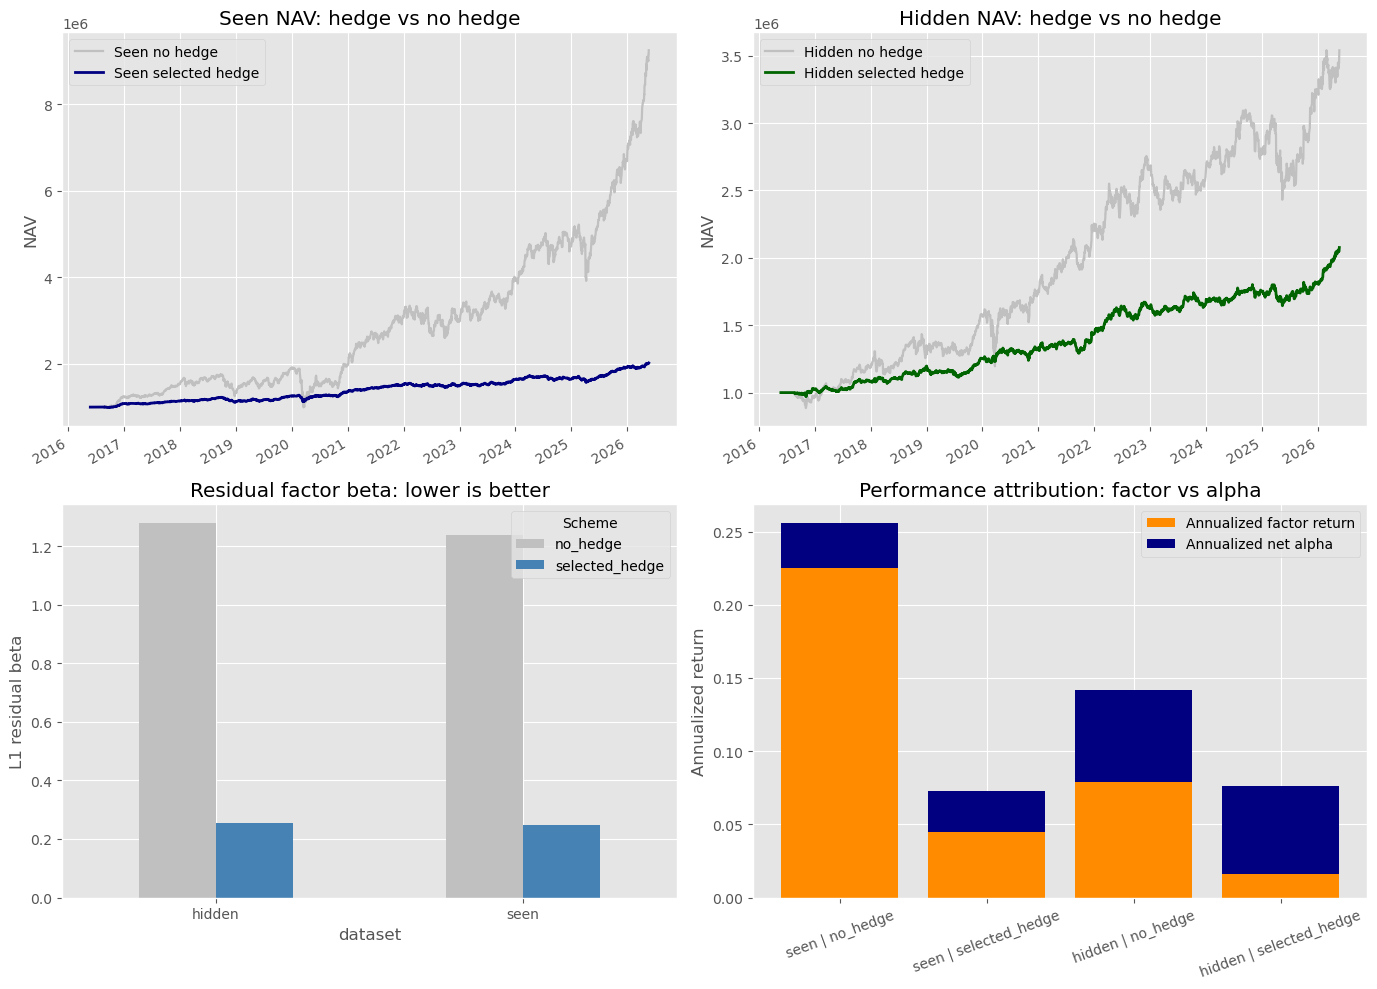

In [30]:
seen_no_hedge = seen_results[0.0]
hidden_no_hedge_diagnostics, hidden_no_hedge_summary, hidden_no_hedge_beta_history, hidden_no_hedge_residual_beta_history = run_factor_hedge_model(
    prices=adj_close,
    selected_assets=HIDDEN_ASSETS,
    factor_etfs=FACTOR_ETFS,
    beta_reduction=0.0,
)

seen_no_hedge_alpha_frame, seen_no_hedge_alpha_summary = compute_alpha_attribution(
    diagnostics=seen_no_hedge["diagnostics"],
    residual_beta_history=seen_no_hedge["residual_beta_history"],
    factor_returns=factor_returns,
    label="seen_no_hedge",
)
hidden_no_hedge_alpha_frame, hidden_no_hedge_alpha_summary = compute_alpha_attribution(
    diagnostics=hidden_no_hedge_diagnostics,
    residual_beta_history=hidden_no_hedge_residual_beta_history,
    factor_returns=factor_returns,
    label="hidden_no_hedge",
)

validation_table = pd.DataFrame(
    [
        pd.Series({
            "dataset": "seen",
            "scheme": "no_hedge",
            "beta_reduction": 0.0,
            "score_sr": seen_no_hedge["summary"]["score_sr"],
            "sortino": seen_no_hedge["summary"]["sortino"],
            "annualized_return": seen_no_hedge["summary"]["annualized_return"],
            "avg_residual_beta_l1": seen_no_hedge["summary"]["avg_residual_beta_l1"],
            "residual_beta_reduction_pct": seen_no_hedge["summary"]["residual_beta_reduction_pct"],
            "annualized_alpha_net": seen_no_hedge_alpha_summary["annualized_alpha_net"],
            "annualized_factor_return": seen_no_hedge_alpha_summary["annualized_factor_return"],
        }),
        pd.Series({
            "dataset": "seen",
            "scheme": "selected_hedge",
            "beta_reduction": best_beta_reduction,
            "score_sr": best_seen["summary"]["score_sr"],
            "sortino": best_seen["summary"]["sortino"],
            "annualized_return": best_seen["summary"]["annualized_return"],
            "avg_residual_beta_l1": best_seen["summary"]["avg_residual_beta_l1"],
            "residual_beta_reduction_pct": best_seen["summary"]["residual_beta_reduction_pct"],
            "annualized_alpha_net": seen_alpha_summary["annualized_alpha_net"],
            "annualized_factor_return": seen_alpha_summary["annualized_factor_return"],
        }),
        pd.Series({
            "dataset": "hidden",
            "scheme": "no_hedge",
            "beta_reduction": 0.0,
            "score_sr": hidden_no_hedge_summary["score_sr"],
            "sortino": hidden_no_hedge_summary["sortino"],
            "annualized_return": hidden_no_hedge_summary["annualized_return"],
            "avg_residual_beta_l1": float(hidden_no_hedge_residual_beta_history.abs().sum(axis=1).mean()),
            "residual_beta_reduction_pct": 0.0,
            "annualized_alpha_net": hidden_no_hedge_alpha_summary["annualized_alpha_net"],
            "annualized_factor_return": hidden_no_hedge_alpha_summary["annualized_factor_return"],
        }),
        pd.Series({
            "dataset": "hidden",
            "scheme": "selected_hedge",
            "beta_reduction": best_beta_reduction,
            "score_sr": hidden_summary["score_sr"],
            "sortino": hidden_summary["sortino"],
            "annualized_return": hidden_summary["annualized_return"],
            "avg_residual_beta_l1": float(hidden_residual_beta_history.abs().sum(axis=1).mean()),
            "residual_beta_reduction_pct": float(1.0 - hidden_residual_beta_history.abs().sum(axis=1).mean() / hidden_no_hedge_residual_beta_history.abs().sum(axis=1).mean()) if hidden_no_hedge_residual_beta_history.abs().sum(axis=1).mean() > 0 else 0.0,
            "annualized_alpha_net": hidden_alpha_summary["annualized_alpha_net"],
            "annualized_factor_return": hidden_alpha_summary["annualized_factor_return"],
        }),
    ]
)

display(validation_table.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seen_no_hedge["diagnostics"]["nav"].plot(ax=axes[0, 0], color="silver", lw=1.6, label="Seen no hedge")
best_seen["diagnostics"]["nav"].plot(ax=axes[0, 0], color="navy", lw=2.0, label="Seen selected hedge")
axes[0, 0].set_title("Seen NAV: hedge vs no hedge")
axes[0, 0].set_ylabel("NAV")
axes[0, 0].legend()

hidden_no_hedge_diagnostics["nav"].plot(ax=axes[0, 1], color="silver", lw=1.6, label="Hidden no hedge")
hidden_diagnostics["nav"].plot(ax=axes[0, 1], color="darkgreen", lw=2.0, label="Hidden selected hedge")
axes[0, 1].set_title("Hidden NAV: hedge vs no hedge")
axes[0, 1].set_ylabel("NAV")
axes[0, 1].legend()

beta_chart = validation_table.pivot(index="dataset", columns="scheme", values="avg_residual_beta_l1")
beta_chart.plot(kind="bar", ax=axes[1, 0], color=["silver", "steelblue"], rot=0)
axes[1, 0].set_title("Residual factor beta: lower is better")
axes[1, 0].set_ylabel("L1 residual beta")
axes[1, 0].legend(title="Scheme")

attribution_chart = validation_table.copy()
attribution_chart["label"] = attribution_chart["dataset"] + " | " + attribution_chart["scheme"]
axes[1, 1].bar(
    attribution_chart["label"],
    attribution_chart["annualized_factor_return"],
    color="darkorange",
    label="Annualized factor return",
)
axes[1, 1].bar(
    attribution_chart["label"],
    attribution_chart["annualized_alpha_net"],
    bottom=attribution_chart["annualized_factor_return"],
    color="navy",
    label="Annualized net alpha",
)
axes[1, 1].set_title("Performance attribution: factor vs alpha")
axes[1, 1].set_ylabel("Annualized return")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend()

plt.tight_layout()
validation_table

,dataset,scheme,window_return,max_drawdown,annualized_vol,downside_deviation,worst_day_return,start_nav,end_nav
0,seen,no_hedge,0.0081,0.2493,0.3646,0.2584,-0.0911,4.757820e+06,4.796376e+06
1,seen,selected_hedge,-0.0049,0.0826,0.0908,0.0660,-0.0214,1.647866e+06,1.639732e+06
2,hidden,no_hedge,-0.0761,0.2047,0.2290,0.1860,-0.0502,2.781601e+06,2.569799e+06
3,hidden,selected_hedge,-0.0328,0.0864,0.0831,0.0665,-0.0151,1.751619e+06,1.694251e+06


,dataset,drawdown_saved_bps,drawdown_reduction_pct,vol_reduction_pct,worst_day_improvement_bps
0,seen,1667.2946,0.6688,0.7509,697.2673
1,hidden,1182.7757,0.5778,0.6369,351.2138


,dataset,scheme,window_return,max_drawdown,annualized_vol,downside_deviation,worst_day_return,start_nav,end_nav
0,seen,no_hedge,0.008104,0.249299,0.364562,0.258390,-0.091086,4.757820e+06,4.796376e+06
1,seen,selected_hedge,-0.004936,0.082570,0.090818,0.065954,-0.021359,1.647866e+06,1.639732e+06
2,hidden,no_hedge,-0.076144,0.204702,0.228982,0.185960,-0.050179,2.781601e+06,2.569799e+06
3,hidden,selected_hedge,-0.032751,0.086424,0.083137,0.066536,-0.015057,1.751619e+06,1.694251e+06


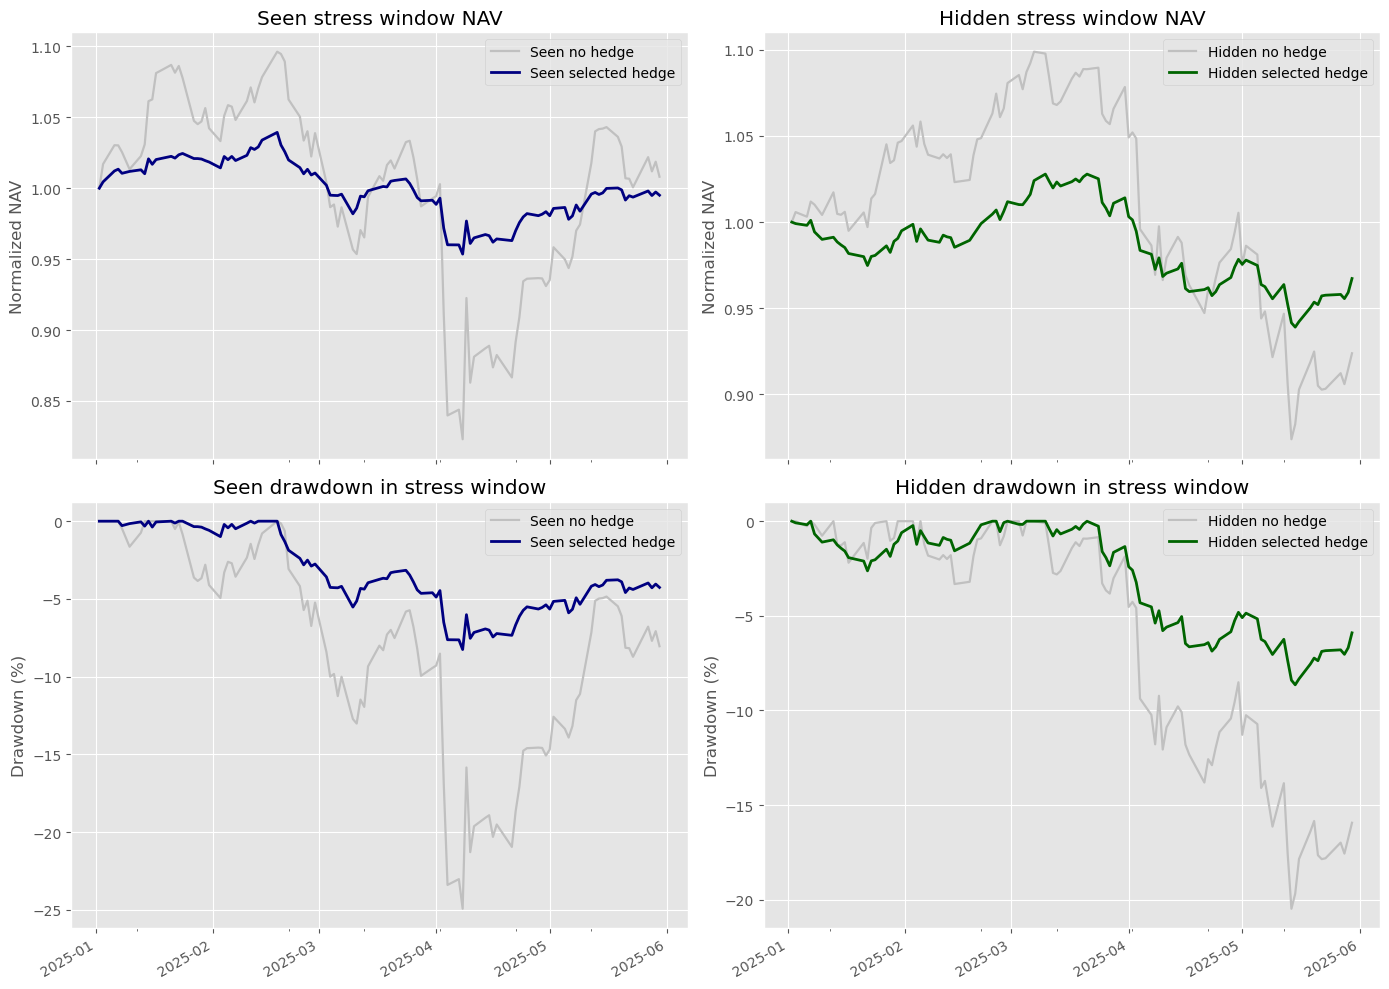

In [31]:
STRESS_START = "2025-01-01"
STRESS_END = "2025-06-01"


def compute_stress_window_metrics(diagnostics: pd.DataFrame, label: str) -> tuple[pd.Series, pd.DataFrame]:
    window = diagnostics.loc[STRESS_START:STRESS_END].copy()
    if window.empty:
        raise ValueError(f"No observations found between {STRESS_START} and {STRESS_END} for {label}.")

    nav = window["nav"].dropna()
    returns = window["return"].reindex(nav.index).fillna(0.0)
    running_peak = nav.cummax()
    drawdown = nav / running_peak - 1.0
    downside = np.minimum(returns, 0.0)

    metrics = pd.Series(
        {
            "window_return": float(nav.iloc[-1] / nav.iloc[0] - 1.0),
            "max_drawdown": float(abs(drawdown.min())),
            "annualized_vol": float(returns.std(ddof=0) * np.sqrt(252)),
            "downside_deviation": float(np.sqrt(252 * np.mean(downside ** 2))),
            "worst_day_return": float(returns.min()),
            "start_nav": float(nav.iloc[0]),
            "end_nav": float(nav.iloc[-1]),
        },
        name=label,
    )

    path = pd.DataFrame(
        {
            "nav": nav,
            "normalized_nav": nav / nav.iloc[0],
            "drawdown": drawdown,
        },
        index=nav.index,
    )
    return metrics, path


seen_no_hedge_stress, seen_no_hedge_path = compute_stress_window_metrics(
    seen_no_hedge["diagnostics"],
    "seen_no_hedge",
)
seen_hedge_stress, seen_hedge_path = compute_stress_window_metrics(
    best_seen["diagnostics"],
    "seen_selected_hedge",
)
hidden_no_hedge_stress, hidden_no_hedge_path = compute_stress_window_metrics(
    hidden_no_hedge_diagnostics,
    "hidden_no_hedge",
)
hidden_hedge_stress, hidden_hedge_path = compute_stress_window_metrics(
    hidden_diagnostics,
    "hidden_selected_hedge",
)

stress_risk_matrix = pd.DataFrame(
    [
        pd.concat([pd.Series({"dataset": "seen", "scheme": "no_hedge"}), seen_no_hedge_stress]),
        pd.concat([pd.Series({"dataset": "seen", "scheme": "selected_hedge"}), seen_hedge_stress]),
        pd.concat([pd.Series({"dataset": "hidden", "scheme": "no_hedge"}), hidden_no_hedge_stress]),
        pd.concat([pd.Series({"dataset": "hidden", "scheme": "selected_hedge"}), hidden_hedge_stress]),
    ]
)

capital_protection_table = pd.DataFrame(
    [
        pd.Series({
            "dataset": "seen",
            "drawdown_saved_bps": float((seen_no_hedge_stress["max_drawdown"] - seen_hedge_stress["max_drawdown"]) * 10_000),
            "drawdown_reduction_pct": float(1.0 - seen_hedge_stress["max_drawdown"] / seen_no_hedge_stress["max_drawdown"]) if seen_no_hedge_stress["max_drawdown"] > 0 else 0.0,
            "vol_reduction_pct": float(1.0 - seen_hedge_stress["annualized_vol"] / seen_no_hedge_stress["annualized_vol"]) if seen_no_hedge_stress["annualized_vol"] > 0 else 0.0,
            "worst_day_improvement_bps": float((seen_hedge_stress["worst_day_return"] - seen_no_hedge_stress["worst_day_return"]) * 10_000),
        }),
        pd.Series({
            "dataset": "hidden",
            "drawdown_saved_bps": float((hidden_no_hedge_stress["max_drawdown"] - hidden_hedge_stress["max_drawdown"]) * 10_000),
            "drawdown_reduction_pct": float(1.0 - hidden_hedge_stress["max_drawdown"] / hidden_no_hedge_stress["max_drawdown"]) if hidden_no_hedge_stress["max_drawdown"] > 0 else 0.0,
            "vol_reduction_pct": float(1.0 - hidden_hedge_stress["annualized_vol"] / hidden_no_hedge_stress["annualized_vol"]) if hidden_no_hedge_stress["annualized_vol"] > 0 else 0.0,
            "worst_day_improvement_bps": float((hidden_hedge_stress["worst_day_return"] - hidden_no_hedge_stress["worst_day_return"]) * 10_000),
        }),
    ]
)

display(stress_risk_matrix.round(4))
display(capital_protection_table.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

seen_no_hedge_path["normalized_nav"].plot(ax=axes[0, 0], color="silver", lw=1.6, label="Seen no hedge")
seen_hedge_path["normalized_nav"].plot(ax=axes[0, 0], color="navy", lw=2.0, label="Seen selected hedge")
axes[0, 0].set_title("Seen stress window NAV")
axes[0, 0].set_ylabel("Normalized NAV")
axes[0, 0].legend()

hidden_no_hedge_path["normalized_nav"].plot(ax=axes[0, 1], color="silver", lw=1.6, label="Hidden no hedge")
hidden_hedge_path["normalized_nav"].plot(ax=axes[0, 1], color="darkgreen", lw=2.0, label="Hidden selected hedge")
axes[0, 1].set_title("Hidden stress window NAV")
axes[0, 1].set_ylabel("Normalized NAV")
axes[0, 1].legend()

(seen_no_hedge_path["drawdown"] * 100).plot(ax=axes[1, 0], color="silver", lw=1.6, label="Seen no hedge")
(seen_hedge_path["drawdown"] * 100).plot(ax=axes[1, 0], color="navy", lw=2.0, label="Seen selected hedge")
axes[1, 0].set_title("Seen drawdown in stress window")
axes[1, 0].set_ylabel("Drawdown (%)")
axes[1, 0].legend()

(hidden_no_hedge_path["drawdown"] * 100).plot(ax=axes[1, 1], color="silver", lw=1.6, label="Hidden no hedge")
(hidden_hedge_path["drawdown"] * 100).plot(ax=axes[1, 1], color="darkgreen", lw=2.0, label="Hidden selected hedge")
axes[1, 1].set_title("Hidden drawdown in stress window")
axes[1, 1].set_ylabel("Drawdown (%)")
axes[1, 1].legend()

plt.tight_layout()
stress_risk_matrix

### Stress-Window Interpretation

The capital-protection effect is clear in the current stress-window results:

- `seen` max drawdown improved from about `24.93%` to `8.26%`.
- `hidden` max drawdown improved from about `20.47%` to `8.64%`.
- `seen` drawdown saved: about `1667` bps.
- `hidden` drawdown saved: about `1183` bps.
- `seen` annualized volatility dropped by about `75.1%`.
- `hidden` annualized volatility dropped by about `63.7%`.

This shows the hedge is doing what it is supposed to do in a difficult window: it sacrifices some upside in exchange for materially better capital preservation, smaller peak-to-trough losses, and lower realized risk.

### Stress-Window Capital Protection

The tables and charts below isolate the `2025-01-01` to `2025-06-01` stress window and compare hedge versus no hedge on drawdown and risk. This is meant to show whether the hedge improves capital protection during a difficult segment of the path.

## 8. Definitions

- **ETF factors**: the sector ETFs used as the explanatory return drivers in the factor model.
- **Target assets**: the individual equities whose returns are modeled against the ETF factor panel.
- **Portfolio beta vector**: the average factor loading of the selected asset basket to the ETF factors.
- **Beta reduction**: hedge intensity between `0` and `1`. `0` means no hedge. `1` means full offset of the estimated portfolio factor beta vector.
- **Residual beta**: factor exposure left after applying the ETF hedge. Under this simple construction it is approximately $(1 - \\lambda) \\beta$, where $\\lambda$ is the beta-reduction control.
- **Alpha attribution**: realized portfolio return minus the portion explained by the residual ETF factor exposure.
- **Hedge effectiveness**: improvement in residual factor exposure or risk-adjusted performance relative to the `0.0` no-hedge baseline.
- **Generalization check**: using the beta-reduction level selected on the seen sectors and then applying it unchanged to the hidden sector.

## 9. Theory And Step-By-Step Construction

This section summarizes the hedge model in the same order used by the notebook. For clarity, the equations below describe the core factor hedge without transaction costs.

### Step 1. Define factor returns and target returns

Let $f_t \in \mathbb{R}^K$ be the ETF factor return vector at time $t$, where each component is one sector ETF return. Let $r_{i,t}$ be the return of target asset $i$.

$$
f_t =
\begin{bmatrix}
r_{\text{SOXX},t} \\
r_{\text{XLE},t} \\
r_{\text{XLF},t} \\
r_{\text{XLV},t}
\end{bmatrix},
\qquad
r_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1
$$

The ETF panel is the factor matrix, and the equities are the targets whose returns we want to hedge.

### Step 2. Estimate rolling factor exposures

For each asset $i$, estimate a rolling linear factor model over the lookback window:

$$
r_{i,t} = \alpha_i + \beta_i^{\top} f_t + \varepsilon_{i,t}
$$

where:

- $\alpha_i$ is the intercept for asset $i$.
- $\beta_i \in \mathbb{R}^K$ is the ETF factor loading vector.
- $\varepsilon_{i,t}$ is the idiosyncratic residual.

In matrix form, each rolling window solves an ordinary least squares problem.

### Step 3. Aggregate asset betas into a portfolio beta vector

If the selected asset basket has weights $w_i$, then the portfolio factor exposure is the weighted sum of asset betas:

$$
\beta_{p} = \sum_i w_i \beta_i
$$

In this notebook the long asset sleeve is equally weighted, so with $N$ selected assets:

$$
w_i = \frac{1}{N},
\qquad
\beta_p = \frac{1}{N} \sum_{i=1}^{N} \beta_i
$$

This gives one portfolio beta vector across all ETF factors.

### Step 4. Choose a beta-reduction control

Let $\lambda \in [0,1]$ be the hedge intensity parameter:

- $\lambda = 0$: no ETF hedge
- $\lambda = 1$: full hedge of the estimated portfolio beta vector
- $0 < \lambda < 1$: partial hedge

The ETF hedge weights are set to:

$$
w_{\text{hedge}} = -\lambda \, \beta_p
$$

### Step 5. Compute the residual factor exposure

After applying the hedge, the remaining factor exposure is:

$$
\beta_{\text{residual}} = \beta_p + w_{\text{hedge}} = (1 - \lambda) \beta_p
$$

This is the key control object in the notebook. As $\lambda$ increases, residual factor exposure falls.

### Step 6. Form the hedged portfolio return

Ignoring transaction costs, the one-period portfolio return is the sum of the asset-leg return and the ETF-hedge return:

$$
r_{p,t} = \sum_i w_i r_{i,t} + w_{\text{hedge}}^{\top} f_t
$$

This is the return stream evaluated over time for each candidate $\lambda$.

### Step 7. Sweep the hedge vector from 0 to 1

The notebook evaluates a grid of hedge intensities:

$$
\lambda \in \{0.0, 0.1, 0.2, \dots, 1.0\}
$$

For each value, it computes the hedged portfolio path and summary statistics, then chooses the best value on the seen sectors.

### Step 8. Select the hedge using seen-sector performance

The selected hedge level is the one that maximizes the evaluation score on the seen sectors, subject to a meaningful reduction in residual beta exposure. Conceptually:

$$
\lambda^* = \arg\max_{\lambda} \; S_R(\lambda)
$$

with an eligibility filter requiring sufficient beta reduction before selecting the final candidate.

### Step 9. Validate on the hidden sector

After choosing $\lambda^*$ on the seen sectors, the same hedge intensity is applied unchanged to the hidden sector. This tests whether the hedge design generalizes rather than only fitting the seen set.

### Step 10. Interpret alpha after hedging

Once the hedge is applied, alpha is defined as the realized portfolio return minus the return explained by the residual factor exposure:

$$
\alpha_t = r_{p,t} - \beta_{\text{residual},t-1}^{\top} f_t
$$

So the model separates performance into:

- factor-driven return explained by the remaining ETF beta
- residual return attributed to alpha

This is why the alpha section naturally follows the hedge-optimization and hidden-sector validation sections.